In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [145]:
Mouse_parent_folders = {
    #"restricted": r"X:\3darena_behavior\wildtype_062425\011725_9\011725_9_restricted_arena_041025\cluster_output\Combined_Results\Results",
    #"openf": r"Y:\3darena_behavior\wildtype_062425\011725_9\011725_9_open_arena_052325\cluster_output\Results\test1",
    #"arenah": r"Y:\3darena_behavior\wildtype_062425\011725_9\011725_9_3d_arenah_070225\cluster_output\Combined_Results\Results\test1",
    #"wildtype": r"X:\Members\Mia-Sanjana-Hadent\Visualizations\Output_wildtype_test - old\data", 
    #"Stitched_DLS": r"Y:\3darena_chemogenetic\c1_041626\042126_m2_dls\cluster_ouput_042126_m2_dls+LargeOF+High_Tier\Combined_Results\Results\test1",
    "dls": r"Y:\3darena_chemogenetic\c1_041626\042126_m2_dls\cluster_output_042126_m2_dls_3d_arena_h+baseline+inhibition\Combined_Results\Results\test1\test1",
    #"dls_mtier": r"X:\3darena_chemogenetic\c1_041626\042126_m2_dls\cluster_output_042126_m2dls_3d_arena_m+bl+i\Combined_Results\Results\test1"
}

In [146]:
TOT_ACCEL_THRESHOLD = 0.049787068367864

In [147]:

for mouse_name, parent_folder in Mouse_parent_folders.items():
    combined_matrix = pd.read_csv(os.path.join(parent_folder, f'combined_results_{mouse_name}_with_features.csv'))
    full_feature_df = pd.read_csv(os.path.join(parent_folder, 'full_feature.csv'))
    full_feature_df["Cluster"] = combined_matrix["Cluster"].repeat(60).values
    full_feature_df["Folder_Name"] = combined_matrix["Folder_Name"].repeat(60).values

    features = ['anterior_posterior_x_accel', 'dorsal_ventral_y_accel', 'y_gyro', 'TotAccelBA']
    for folder in full_feature_df["Folder_Name"].unique():
        subset = full_feature_df[full_feature_df["Folder_Name"] == folder]
        subset = subset.replace([np.inf, -np.inf], np.nan)
        subset.dropna(inplace=True)

        print(folder)
        for feature in features:
            print(f"\tAverage {feature}: {subset[feature].mean()}")

1.0
	Average anterior_posterior_x_accel: 0.7664684887814522
	Average dorsal_ventral_y_accel: 0.16595665427602868
	Average y_gyro: 0.7673086467077377
	Average TotAccelBA: -1.0334106927157791
2.0
	Average anterior_posterior_x_accel: 0.6914813942934979
	Average dorsal_ventral_y_accel: -0.01033409374614551
	Average y_gyro: 1.1246395908725317
	Average TotAccelBA: -1.323621916023074


In [185]:
def find_cluster_with_condition(parent_folder, mouse_name):
    combined_matrix = pd.read_csv(os.path.join(parent_folder, f'combined_results_{mouse_name}_with_features.csv'))
    full_feature_df = pd.read_csv(os.path.join(parent_folder, 'full_feature.csv'))
    full_feature_df["Cluster"] = combined_matrix["Cluster"].repeat(60).values
    
    climbing_condition =(full_feature_df["anterior_posterior_x_accel"] > -0.4 ) & (full_feature_df["anterior_posterior_x_accel"] < 0) & (full_feature_df["TotAccelBA"] > TOT_ACCEL_THRESHOLD )
    downward_climbing_condition =(full_feature_df["anterior_posterior_x_accel"] > 0.4 )  & (full_feature_df["TotAccelBA"] > TOT_ACCEL_THRESHOLD*2 ) & (full_feature_df["TotAccelBA"] < TOT_ACCEL_THRESHOLD*4 )
    fast_condition =(full_feature_df["TotAccelBA"] > TOT_ACCEL_THRESHOLD*4 )
    walking_condition = (full_feature_df["TotAccelBA"] > TOT_ACCEL_THRESHOLD/6 ) & (full_feature_df["TotAccelBA"] < TOT_ACCEL_THRESHOLD/4 )
    rearing_condition = full_feature_df["anterior_posterior_x_accel"] < -0.6
    stretching_condition = (full_feature_df["dorsal_ventral_y_accel"] > 0.662) & (full_feature_df["dorsal_ventral_y_accel"] < 0.662*3)
    condition = stretching_condition

    total = full_feature_df.groupby("Cluster").size()
    negative = full_feature_df[condition ].groupby("Cluster").size()

    pct = (negative / total * 100).fillna(0)
    
    pct_df = pd.DataFrame({"Cluster": pct.index, "Percent": pct.values}, index=[0 for i in full_feature_df["Cluster"].unique()])
    pct_df.sort_values("Percent", ascending=False, inplace=True)
    print (f"Mouse: {mouse_name}")
    print(pct_df.head(10))
    print("===================================")

In [186]:
for mouse_name, parent_folder in Mouse_parent_folders.items():
    find_cluster_with_condition(parent_folder, mouse_name)

Mouse: dls
   Cluster    Percent
0     17.0  90.221852
0     40.0  88.839907
0     42.0  86.636193
0     43.0  82.731481
0     39.0  82.155934
0     33.0  77.914172
0     36.0  73.056527
0     41.0  70.932765
0     10.0  59.122096
0      5.0  58.989637


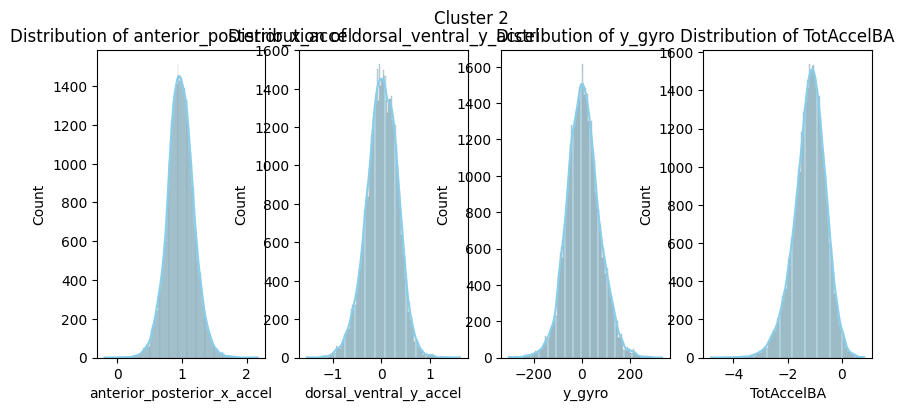

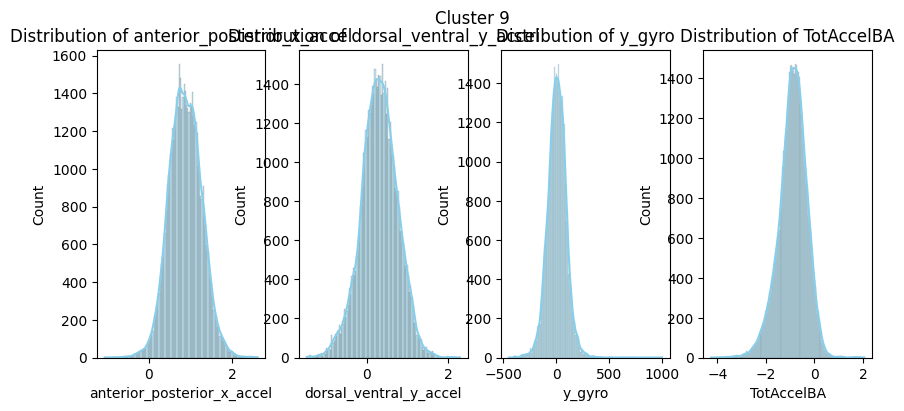

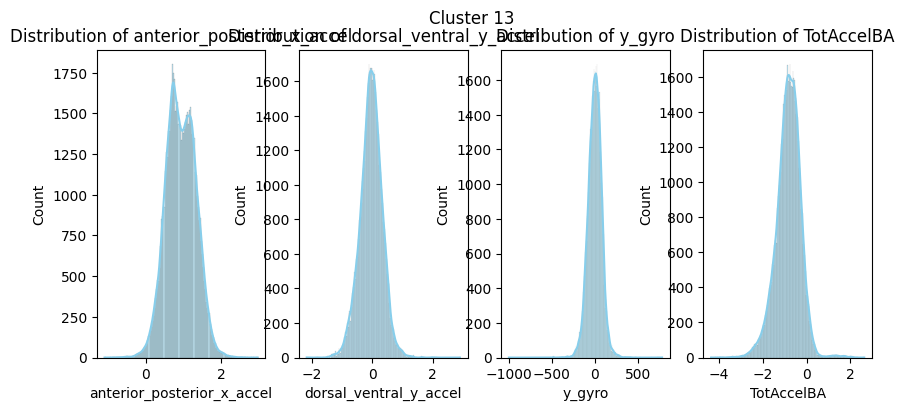

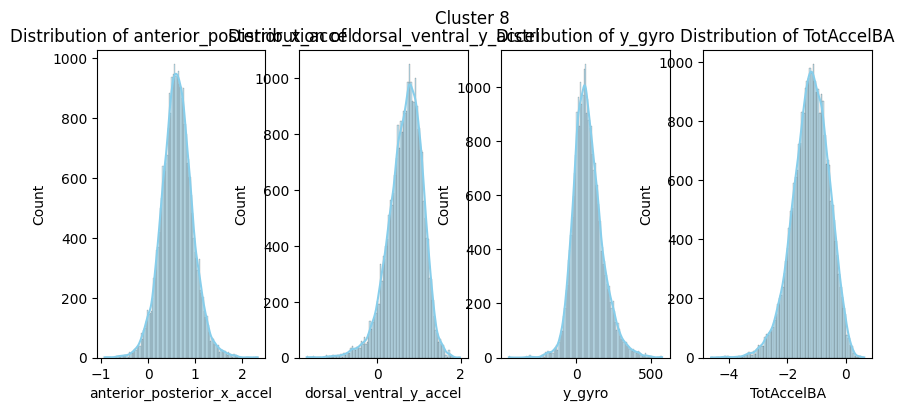

In [98]:
focus = [2, 9, 13, 8]
for mouse_name, parent_folder in Mouse_parent_folders.items():
    combined_matrix = pd.read_csv(os.path.join(parent_folder, f'combined_results_{mouse_name}_with_features.csv'))
    full_feature_df = pd.read_csv(os.path.join(parent_folder, 'full_feature.csv'))
    full_feature_df["Cluster"] = combined_matrix["Cluster"].repeat(60).values
    

    # 3. Loop through your columns and map them to the axes
    features = ['anterior_posterior_x_accel', 'dorsal_ventral_y_accel', 'y_gyro', 'TotAccelBA']
    for c in focus:
        fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(10, 4))

        cluster_subset = full_feature_df[full_feature_df["Cluster"] == c]
        
        # 2. Flatten the 2D array of axes to easily loop through them 1-by-1
        axs = axs.flatten()
        for i, col in enumerate(features):
            sns.histplot(data=cluster_subset, x=col, kde=True, ax=axs[i], color="skyblue")
            axs[i].set_title(f"Distribution of {col}")
        
        fig.suptitle(f"Cluster {c}")

In [175]:
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
def plot_histogram_of_accel(parent_folder, mouse_name, log=True):
    combined_matrix = pd.read_csv(os.path.join(parent_folder, f'combined_results_{mouse_name}_with_features.csv'))
    full_feature_df = pd.read_csv(os.path.join(parent_folder, 'full_feature.csv'))
    full_feature_df["Cluster"] = combined_matrix["Cluster"].repeat(60).values
    full_feature_df["Folder_Name"] = combined_matrix["Folder_Name"].repeat(60).values

    accel = full_feature_df['dorsal_ventral_y_accel']

    # Remove inf
    accel = accel.replace([np.inf, -np.inf], np.nan)
    accel.dropna(inplace=True)
    
    # Log-transform
    if log:
        accel = accel[accel > 0]
        log_accel = np.log(accel)
    else:
        log_accel = accel

    # Histogram
    hist, edges = np.histogram(log_accel, bins=100, density=True)
    centers = (edges[:-1] + edges[1:]) / 2

    # Smooth histogram
    hist_smooth = gaussian_filter1d(hist, sigma=2)

    # Find peaks
    peaks, _ = find_peaks(hist_smooth)

    if len(peaks) >= 2:

        # Sort by peak height
        top_peaks = peaks[np.argsort(hist_smooth[peaks])[-2:]]
        top_peaks = np.sort(top_peaks)

        # Valley between peaks
        valley_region = hist_smooth[top_peaks[0]:top_peaks[1]]
        valley_idx = np.argmin(valley_region) + top_peaks[0]
        threshold = centers[valley_idx]

        print(f"Threshold (log scale): {threshold:.4f}")
        print(f"Threshold (original scale): {10**threshold:.4f}")

    # Plot
    plt.figure(figsize=(8,6))
    plt.hist(log_accel, bins=100, density=True, alpha=0.4)

    plt.plot(centers, hist_smooth, linewidth=2)
    if len(peaks) >= 2:
        plt.axvline(threshold, linestyle='--',
                label=f'Threshold = {threshold:.3f}')
    x_label = "Total Dynamic Acceleration"
    if log:
        x_label = f"log({x_label})"
    plt.xlabel(x_label)
    plt.ylabel('Density')
    plt.title('Bimodal Acceleration Distribution')
    plt.legend()

    plt.show()

dls
Threshold (log scale): 0.6619
Threshold (original scale): 4.5906


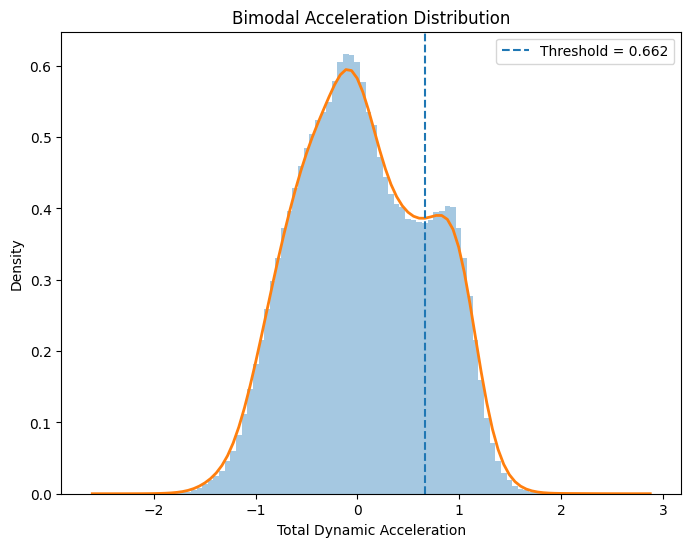

In [176]:
for mouse_name, parent_folder in Mouse_parent_folders.items():
    print(mouse_name)
    plot_histogram_of_accel(parent_folder, mouse_name, log=False)

In [ ]:
from matplotlib.patches import Patch
def plot_cluster_accel(parent_folder, mouse_name, low_thresh, high_thresh, 
                       save_path="cluster_accel.png"):
    df = pd.read_csv(os.path.join(parent_folder, f'combined_results_{mouse_name}_with_features.csv'))

    color_map = {"Low": "#4C72B0", "Medium": "#DD8452", "High": "#C44E52"}

    def classify(val):
        if val < low_thresh:
            return "Low"
        elif val < high_thresh:
            return "Medium"
        else:
            return "High"

    cluster_means = df.groupby("Cluster")["TotAccelBA"].mean().reset_index()
    cluster_means.columns = ["Cluster", "MeanAccel"]
    cluster_means["Level"] = cluster_means["MeanAccel"].apply(classify)
    
    cluster_means = cluster_means.sort_values("MeanAccel").reset_index(drop=True)
    colors = cluster_means["Level"].map(color_map)

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.bar(cluster_means["Cluster"].astype(int).astype(str), cluster_means["MeanAccel"],
           color=colors, edgecolor="white", linewidth=0.5)

    legend_elements = [Patch(facecolor=color_map[l], label=l) 
                       for l in ["Low", "Medium", "High"]]
    ax.legend(handles=legend_elements, title="Activity Level")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Mean TotAccelBA")
    ax.set_title("Mean Acceleration per Cluster")
    ax.axhline(low_thresh,  color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axhline(high_thresh, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

In [ ]:
for mouse_name, parent_folder in Mouse_parent_folders.items():
    plot_cluster_accel(parent_folder, mouse_name, low_thresh=TOT_ACCEL_THRESHOLD, high_thresh=0.2)

In [ ]:
plot_cluster_accel(r"X:\3darena_chemogenetic\c1_041626\042126_m2_dls\cluster_output_042126_m2_dls_3d_arena_h+baseline+inhibition\Combined_Results\Results\test1", mouse_name="dls_hight", low_thresh=TOT_ACCEL_THRESHOLD, high_thresh=0.2)

420.7848 1108.2352


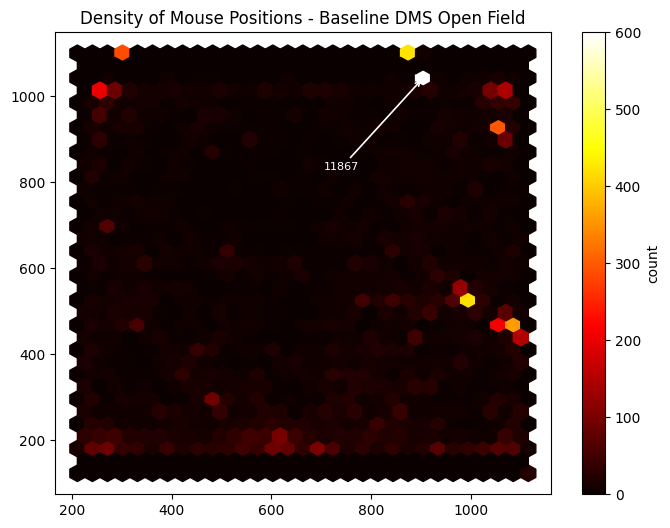

113.5371 655.5929


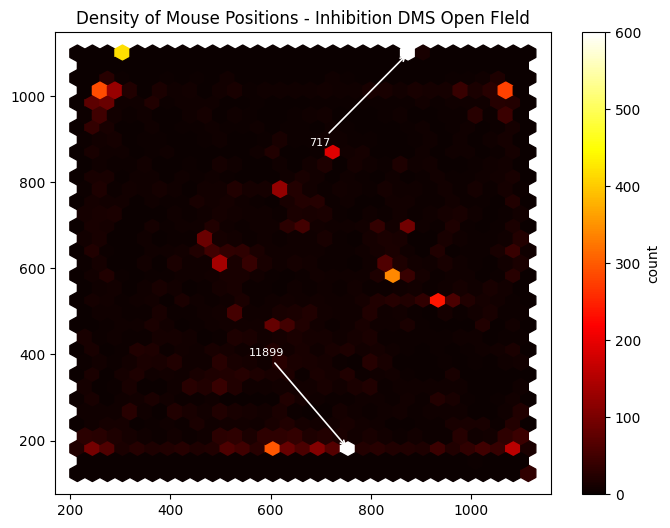

In [10]:
Centroid_Mice = {
    #"Baseline High Tier": r"D:\from desktop\Hadents Folder\Centroid mapping\dls_hightier\output_bl\cluster_positions.csv",
    #"Inhibition High Tier": r"D:\from desktop\Hadents Folder\Centroid mapping\dls_hightier\output_i\cluster_positions.csv",
    #"Highdose Inhibition High Tier": r"D:\from desktop\Hadents Folder\Centroid mapping\dls_hightier\output_highdose\cluster_positions.csv"
    #"Baseline Mid Tier": r"D:\from desktop\Hadents Folder\Centroid mapping\dls_midtier\output_bl\cluster_positions.csv",
    #"Inhibition Mid Tier": r"D:\from desktop\Hadents Folder\Centroid mapping\dls_midtier\output_i\cluster_positions.csv",
    #"Baseline Open Field": r"D:\from desktop\Hadents Folder\Centroid mapping\dls_openfield\output_bl\cluster_positions.csv",
    #"Inhibition Open Field": r"D:\from desktop\Hadents Folder\Centroid mapping\dls_openfield\output_i\cluster_positions.csv",
    #"Baseline DMS High Tier": r"D:\from desktop\Hadents Folder\Centroid mapping\dms_hightier\output_bl\cluster_positions.csv",
    #"Inhibition DMS High Tier": r"D:\from desktop\Hadents Folder\Centroid mapping\dms_hightier\output_i\cluster_positions.csv",
    "Baseline DMS Open Field": r"D:\from desktop\Hadents Folder\Centroid mapping\dms_openfield\output_bl\cluster_positions.csv",
    "Inhibition DMS Open FIeld": r"D:\from desktop\Hadents Folder\Centroid mapping\dms_openfield\output_i\cluster_positions.csv"
}
def clip_outliers(df, cols=["y"], factor=0.15):
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        df[col] = df[col].clip(113, 1100)
        print(lower, upper)
    return df

def plot_mouse_pos_density(csv_path, mouse_name, vmax=600):
    df = pd.read_csv(csv_path)
    df = clip_outliers(df)

    fig, ax = plt.subplots(figsize=(8, 6))
    hb = ax.hexbin(df["x"], df["y"], gridsize=30, cmap="hot", vmax=vmax)
    fig.colorbar(hb, ax=ax, label="count")

    counts = hb.get_array()
    offsets = hb.get_offsets()

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    x_range = x_max - x_min
    y_range = y_max - y_min
    offset_frac = 0.2  # how far to push the label as fraction of axis range

    for (x, y), count in zip(offsets, counts):
        if count > vmax:

            # horizontal: close to right → push left, else push right
            if (x - x_min) / x_range > 0.5:
                label_x = x - x_range * offset_frac
            else:
                label_x = x + x_range * offset_frac

            # vertical: close to top → push down, else push up
            if (y - y_min) / y_range > 0.5:
                label_y = y - y_range * offset_frac
            else:
                label_y = y + y_range * offset_frac

            ax.annotate(
                f"{int(count)}",
                xy=(x, y),
                xytext=(label_x, label_y),
                color="white",
                fontsize=8,
                arrowprops=dict(arrowstyle="->", color="white", lw=1.2),
            )

    ax.set_title(f"Density of Mouse Positions - {mouse_name}")
    plt.savefig(f"Density_of_Mouse_Positions_{mouse_name.replace(' ', '_')}")
    plt.show()

for mouse_name, parent_folder in Centroid_Mice.items():
    plot_mouse_pos_density(parent_folder, mouse_name)

In [11]:
from scipy.stats import entropy
import numpy as np

def get_mouse_entropy(csv_path, mouse_name, gridsize=30):
    df = pd.read_csv(csv_path)
    df = clip_outliers(df)
    
    counts, _, _ = np.histogram2d(df["x"], df["y"], bins=gridsize)
    flat = counts.flatten()
    flat = flat[flat > 0]          # remove empty bins
    probs = flat / flat.sum()      # normalize to probability distribution
    h = entropy(probs, base=2)     # entropy in bits

    print(f"{mouse_name}: entropy = {h:.3f} bits")
    return h

entropies = {}
for mouse_name, csv_path in Centroid_Mice.items():
    entropies[mouse_name] = get_mouse_entropy(csv_path, mouse_name)

420.7848 1108.2352
Baseline DMS Open Field: entropy = 5.223 bits
113.5371 655.5929
Inhibition DMS Open FIeld: entropy = 5.164 bits


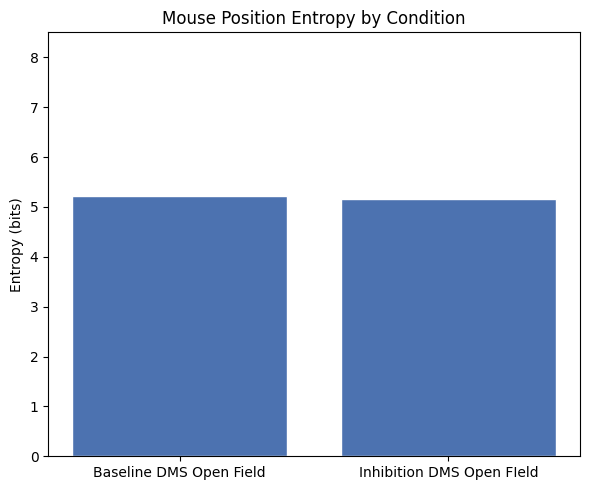

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.bar(entropies.keys(), entropies.values(), color="#4C72B0", edgecolor="white")
plt.ylabel("Entropy (bits)")
plt.title("Mouse Position Entropy by Condition")
plt.ylim(top=8.5)
plt.tight_layout()
plt.savefig("Mouse_Position_Entropy_by_Condition")
plt.show()